In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import os
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

import sys
sys.path.append('..')
from basicfunc import MouseAnatomyTree, bootstrap_stat_test

import scipy
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, mutual_info_score

import pymrmr
from sklearn.model_selection import cross_validate, LeaveOneOut, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from scipy.stats import wilcoxon

import warnings
warnings.filterwarnings("ignore")


In [ ]:
used_morpho_features = ['Center Shift', 'Average Contraction',
       'Average Bifurcation Angle Remote', 
       'Max Branch Order', 'Number of Bifurcations', 'Total Length',
       'Max Path Distance',
       'Average Euclidean Distance', 'Average Path Distance', '3D Density',
       'Volume',]
mapped_cols = ['Center Shift','Avg. Straightness','Avg. Remote Bifur Angle',
                       'Max Branch Order','Bifur Num','Total Length','Max Path Dist','Avg. Euclidean Dist',
                      'Avg. Path Dist','3D Density','Volume']
feat_mapping_dict = dict(zip(used_morpho_features,mapped_cols))


homo_color_lut = {
                 'FL':np.array([255,206,72])/255.0,
                 'PL':np.array([153,217,234])/255.0,
                 'TL':np.array([118,137,211])/255.0}

# mouse
color1 = np.array([29/255,140/255,67/255])
# human
color2 = np.array([255,102,102])/255.0
# reference dataset
color3=np.array([191,200,215])/255.0

In [ ]:
# Whether to only consider pyramidal cells in layer 2/3
pyr23_only = False

In [ ]:
mouse_anatomy_tree = MouseAnatomyTree('../Data/external/tree.json')

# cell type
df_ct_mouse = pd.read_csv(r'..\Data\metadata\mouse_celltype.csv',index_col=0)
if pyr23_only:
    df_ct_mouse = df_ct_mouse[df_ct_mouse['layer'].isin(['2/3'])]
    df_ct_mouse = df_ct_mouse[df_ct_mouse['is_pyramidal']==1]
else:
    df_ct_mouse = df_ct_mouse[df_ct_mouse['layer'].isin(['2/3', '5'])]
    df_ct_mouse = df_ct_mouse[df_ct_mouse['is_pyramidal']==1]
    
    pass

df_ct_human = pd.read_csv(r'..\Data\metadata\human_celltype.csv',index_col=0)
if pyr23_only:
    df_ct_human = df_ct_human[df_ct_human['layer'].isin(['L2/3'])]
    df_ct_human = df_ct_human[df_ct_human['is_pyramidal']==1]
else:
    df_ct_human = df_ct_human[df_ct_human['is_pyramidal']==1]
    pass

# morphology features of cropped swc
crop_thres_list = [50,]
restem = 8
path_morpho = r'..\Data\Morphology'
path_nbranch = r'..\Data\Morphology'

dict_df_morpho_mouse = {}
for crop_thres in crop_thres_list:
    tmpdf = pd.read_csv(os.path.join(path_morpho, f"mouse_apical_morphology_restem{restem}_crop{crop_thres}.csv"), index_col=0)[used_morpho_features]
    # tmpdf['3D Density'] = (tmpdf['3D Density']+0).apply(np.log10)
    tmpdf['3D Density'] = (tmpdf['Total Length']/tmpdf['Volume']).apply(np.log10)
    tmpdf['Volume'] = (tmpdf['Volume']+1).apply(np.log10)
    tmpdf.columns = [feat_mapping_dict[x] for x in tmpdf.columns]
    
    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"mouse_apical_n_branch_num_restem{restem}_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    del tmptmpdf['1']
    tmptmpdf.columns = [f"L{int(x)} Branch Num" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)

    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"mouse_apical_n_branch_length_restem{restem}_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Length" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmpdf.columns = ["A_" + x for x in tmpdf.columns]
    
    tmptmpdf = pd.read_csv(os.path.join(path_morpho, f"mouse_basal_morphology_restem{restem}_crop{crop_thres}.csv"), index_col=0)[used_morpho_features]
    # tmpdf['3D Density'] = (tmpdf['3D Density']+0).apply(np.log10)
    tmptmpdf['3D Density'] = (tmptmpdf['Total Length']/tmptmpdf['Volume']).apply(np.log10)
    tmptmpdf['Volume'] = (tmptmpdf['Volume']+1).apply(np.log10)
    tmptmpdf.columns = [feat_mapping_dict[x] for x in tmptmpdf.columns]
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"mouse_basal_n_branch_num_restem{restem}_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Num" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)

    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"mouse_basal_n_branch_length_restem{restem}_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Length" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmpdf.columns = ["B_" + x if not x.startswith('A_') else x for x in tmpdf.columns]
    
    dict_df_morpho_mouse[crop_thres] = tmpdf
    
dict_df_morpho_human = {}
for crop_thres in crop_thres_list:
    tmpdf = pd.read_csv(os.path.join(path_morpho, f"human_apical_morphology_crop{crop_thres}.csv"), index_col=0)[used_morpho_features]
    # tmpdf['3D Density'] = (tmpdf['3D Density']+0).apply(np.log10)
    tmpdf['3D Density'] = (tmpdf['Total Length']/tmpdf['Volume']).apply(np.log10)
    tmpdf['Volume'] = (tmpdf['Volume']+1).apply(np.log10)
    tmpdf.columns = [feat_mapping_dict[x] for x in tmpdf.columns]

    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"human_apical_n_branch_num_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    del tmptmpdf['1']
    tmptmpdf.columns = [f"L{int(x)} Branch Num" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"human_apical_n_branch_length_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Length" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmpdf.columns = ["A_" + x for x in tmpdf.columns]
    
    tmptmpdf = pd.read_csv(os.path.join(path_morpho, f"human_basal_morphology_crop{crop_thres}.csv"), index_col=0)[used_morpho_features]
    # tmpdf['3D Density'] = (tmpdf['3D Density']+0).apply(np.log10)
    tmptmpdf['3D Density'] = (tmptmpdf['Total Length']/tmptmpdf['Volume']).apply(np.log10)
    tmptmpdf['Volume'] = (tmptmpdf['Volume']+1).apply(np.log10)
    tmptmpdf.columns = [feat_mapping_dict[x] for x in tmptmpdf.columns]
    
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)

    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"human_basal_n_branch_num_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Num" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"human_basal_n_branch_length_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Length" for x in tmptmpdf.columns]
    # tmpdf = pd.concat([tmpdf, tmptmpdf.iloc[:,tmptmpdf.sum(axis=0).values>0]], axis=1)
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmpdf.columns = ["B_" + x if not x.startswith('A_') else x for x in tmpdf.columns]
    
    
    dict_df_morpho_human[crop_thres] = tmpdf
    
    

mouse:  (4522, 7)


In [51]:
def compute_histograms(arr1,arr2,outlier: str='minmax'):
    arr1 = np.array(arr1)
    arr2 = np.array(arr2)

    if outlier not in ['minmax','boxplot']:
        raise ValueError(f'invalid outlier value: {outlier}')
    
    lowb, highb = 0, 0
    
    if outlier=='boxplot':
        Q11,Q12,Q13=np.percentile(arr1, [25,50,75])
        IQR1 = Q13-Q11
        lowb1,highb1 = Q11-1.5*IQR1, Q13+1.5*IQR1
        Q21,Q22,Q23=np.percentile(arr2, [25,50,75])
        IQR2 = Q23-Q21
        lowb2,highb2 = Q21-1.5*IQR2, Q23+1.5*IQR2
        lowb = min(lowb1, lowb2)
        highb = max(highb1, highb2)
    elif outlier=='minmax':
        lowb = min(np.min(arr1),np.min(arr2))
        highb = max(np.max(arr1),np.max(arr2))
        
    arr1_filter = arr1[(arr1>=lowb)&(arr1<=highb)]
    arr2_filter = arr2[(arr2>=lowb)&(arr2<=highb)]
    arr_concat = np.hstack([arr1_filter,arr2_filter])
    ct_arr_concat = [0]*len(arr1_filter)+[1]*len(arr2_filter)
    
    _, bin_edges = np.histogram(arr_concat,bins='auto')
    bin_num = len(bin_edges) - 1
    interval = bin_edges[1]-bin_edges[0]
    
    bin_lowb = np.min(bin_edges)
    bin_highb = np.max(bin_edges)

    hist_fv=[]
    for i,v in enumerate(arr_concat):
        if v<bin_lowb:
            # hist_fv.append(0)
            # print(v,bin_lowb)
            continue
        elif v>bin_highb:
            # hist_fv.append(bin_num-1)
            # print(v,bin_highb)
            continue
        elif v==bin_highb:
            hist_fv.append((v-bin_lowb)//interval-1)
        else:
            hist_fv.append((v-bin_lowb)//interval)
            
    return hist_fv[:len(arr1_filter)], hist_fv[len(arr1_filter):]
    

def DIFF_feat_ct(arr1,arr2,method='JSD',stat_test=True,group1_meta=None,group2_meta=None):
    assert method in ['NMI','JSD','MI','AMI','CORR'], f'unsupported method: {method}'
    def JSD_score(p,q):
        M=(p+q)/2
        output = 0.5*scipy.stats.entropy(p,M,base=2)+0.5*scipy.stats.entropy(q, M,base=2)
        if np.isnan(output):
            return 0.0
        else:
            return output

    
    Q11,Q12,Q13=np.percentile(arr1, [25,50,75])
    IQR1 = Q13-Q11
    lowb1,highb1 = Q11-1.5*IQR1, Q13+1.5*IQR1
    Q21,Q22,Q23=np.percentile(arr2, [25,50,75])
    IQR2 = Q23-Q21
    lowb2,highb2 = Q21-1.5*IQR2, Q23+1.5*IQR2
    lowb = min(lowb1, lowb2)
    highb = max(highb1, highb2)

    
    # arr_concat = np.hstack((arr1[(arr1>=lowb)&(arr1<highb)],arr2[(arr2>=lowb)&(arr2<highb)]))
    # ct_arr = [0]*len(arr1[(arr1>=lowb)&(arr1<highb)])+[1]*len(arr2[(arr2>=lowb)&(arr2<highb)])

    arr_concat = np.hstack([arr1,arr2])
    ct_arr = [0]*len(arr1)+[1]*len(arr2)
    
    # _, bin_edges = np.histogram(arr_concat[(arr_concat>=lowb)&(arr_concat<=highb)],bins='auto')
    _, bin_edges = np.histogram(arr_concat,bins='auto')
    bin_num = len(bin_edges)-1
    interval = bin_edges[1]-bin_edges[0]
    tmparr1 = arr_concat[:len(arr1)]
    tmparr2 = arr_concat[len(arr1):]
    if stat_test:
        pv,sig,cohens_d,pv_mlm = bootstrap_stat_test(arr1,arr2,'mwu',group1_meta=group1_meta,group2_meta=group2_meta)
    else:
        pv,sig,cohens_d,pv_mlm = None, None,None, None
    
    bin_lowb = np.min(bin_edges)
    bin_highb = np.max(bin_edges)

    if method in ['NMI','MI','AMI','CORR']:
        hist_fv=[]
        for i,v in enumerate(arr_concat):
            if v<bin_lowb:
                # hist_fv.append(0)
                # print(v,bin_lowb)
                continue
            elif v>bin_highb:
                # hist_fv.append(bin_num-1)
                # print(v,bin_highb)
                continue
            elif v==bin_highb:
                hist_fv.append((v-bin_lowb)//interval-1)
            else:
                hist_fv.append((v-bin_lowb)//interval)
        if method=='NMI':
            score = normalized_mutual_info_score(hist_fv,ct_arr)
        elif method=='MI':
            score = mutual_info_score(hist_fv,ct_arr)
        elif method=='AMI':
            score = adjusted_mutual_info_score(hist_fv,ct_arr)
        elif method=='CORR':
            score = abs(scipy.stats.pointbiserialr(hist_fv,ct_arr).correlation)
        
    elif method == 'JSD':
        hist_fv1 = np.zeros(bin_num)
        hist_fv2 = np.zeros(bin_num)

        for i,v in enumerate(tmparr1):
            if v<bin_lowb:
                # hist_fv1.append(0)
                continue
            elif v>bin_highb:
                # hist_fv1.append(bin_num-1)
                continue
            elif v==bin_highb:
                hist_fv1[int((v-bin_lowb)//interval-1)]+=1
            else:
                hist_fv1[int((v-bin_lowb)//interval)]+=1
        for i,v in enumerate(tmparr2):
            if v<bin_lowb:
                # hist_fv2.append(0)
                continue
            elif v>bin_highb:
                # hist_fv2.append(bin_num-1)
                continue
            elif v==bin_highb:
                hist_fv2[int((v-bin_lowb)//interval-1)]+=1
            else:
                hist_fv2[int((v-bin_lowb)//interval)]+=1
        hist_fv1 = np.asarray(hist_fv1)/(np.sum(hist_fv1)+1e-10)
        hist_fv2 = np.asarray(hist_fv2)/(np.sum(hist_fv2)+1e-10)
        score = JSD_score(hist_fv1,hist_fv2)
    return score,pv,sig,cohens_d,pv_mlm


In [52]:
'''Comparison of the difference between regions'''
select_cropthres = [50]
df_morpho_mouse = pd.DataFrame()
df_morpho_human = pd.DataFrame()
for crop_thres in select_cropthres:
    tmpdf = dict_df_morpho_mouse[crop_thres].copy()
    tmpdf.columns = [f"R{crop_thres}_"+x for x in tmpdf.columns]
    df_morpho_mouse = pd.concat([df_morpho_mouse, tmpdf], axis=1)
    
    tmpdf = dict_df_morpho_human[crop_thres].copy()
    tmpdf.columns = [f"R{crop_thres}_"+x for x in tmpdf.columns]
    df_morpho_human = pd.concat([df_morpho_human, tmpdf], axis=1)

df_morpho_mouse.dropna(how='any', axis=0, inplace=True)
df_morpho_human.dropna(how='any', axis=0, inplace=True)

print(df_morpho_mouse.shape)

(6604, 41)


In [53]:


SCORE_LIST = ["balanced_accuracy","precision","recall","f1_macro","f1_weighted","roc_auc",]


def classification(X, y, algorithm: str,cv=5, n_components=0.95):
    n_jobs = -1
    
    X=np.asarray(X)
    y=np.asarray(y)
        
    # standardization
    scaler = StandardScaler().fit(X)
    X_standard = scaler.transform(X)

    if n_components==None:
        X_standard_pca = X_standard.copy()
    else:
        pca = PCA(n_components)
        X_standard_pca = pca.fit_transform(X_standard)
        
    
    enc = LabelEncoder().fit(np.unique(y))
    y_numeric = enc.transform(y)
    
    # shuffle
    training_data = np.hstack((X_standard_pca, y_numeric.reshape(-1,1)))
    np.random.seed(821)
    np.random.shuffle(training_data)
    X = training_data[:, :-1]
    y = training_data[:, -1]


    if algorithm=='RF':
        classifier=RandomForestClassifier(n_jobs=n_jobs,class_weight=None,random_state=821)
    elif algorithm=='DT':
        classifier=DecisionTreeClassifier(class_weight='balanced',random_state=821)
    elif algorithm=='LR':
        classifier=LogisticRegression(n_jobs=n_jobs,class_weight='balanced',random_state=821)
    elif algorithm=='QDA':
        classifier=QuadraticDiscriminantAnalysis()
    elif algorithm=='KNN':
        classifier=KNeighborsClassifier(n_neighbors=5, weights='uniform', 
                                    algorithm="auto", leaf_size=30, n_jobs=n_jobs)
    elif algorithm=='SVM':
        classifier=SVC(random_state=821)
    else:
        raise ValueError(f'no model: {algorithm}')
    
    if algorithm=='KNN':
        loo = LeaveOneOut()
        count=0
        y_true=[]
        y_pred=[]
        for train,test in loo.split(X):
            count+=1
            classifier.fit(X[train],y[train])
            result = classifier.predict(X[test])
            y_true.append(y[test][0])
            y_pred.append(result[0])
        cm = confusion_matrix(y_true, y_pred)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        # print("accuracy:",metrics.accuracy_score(y_true,y_pred))
        print("balanced_accuracy:",metrics.balanced_accuracy_score(y_true,y_pred))
        # print("F1-score:",metrics.f1_score(y_true,y_pred,average ='macro'))
    else:
        kf = StratifiedKFold(n_splits=cv,shuffle=True,random_state=821)
        params = {
                    'n_estimators': [100, 200, 300, 400, 500],
                    'min_samples_split' :[2,3,4],
                    'max_depth': [4,5],
                    'max_features': ['sqrt'],
                    'class_weight': ['balanced'],
                    'random_state': [821]
                }
        grid_rf = GridSearchCV(classifier, param_grid=params, cv=kf, n_jobs=n_jobs, refit=False,
                          scoring='balanced_accuracy', return_train_score=True).fit(X, y)
        print('Best parameters:', grid_rf.best_params_)
        mean_train_score = grid_rf.cv_results_['mean_train_score'][grid_rf.best_index_]
        std_train_score = grid_rf.cv_results_['std_train_score'][grid_rf.best_index_]
        mean_test_score = grid_rf.cv_results_['mean_test_score'][grid_rf.best_index_]
        std_test_score = grid_rf.cv_results_['std_test_score'][grid_rf.best_index_]
        print(f"train:{mean_train_score:.3f}±{std_train_score:.3f}",f"test:{mean_test_score:.3f}±{std_test_score:.3f}")

        classifier = type(classifier)(**grid_rf.best_params_)
        # classifier = grid_rf.best_estimator_
        cv = cross_validate(classifier, X, y, cv=kf, n_jobs=n_jobs, scoring=SCORE_LIST, return_train_score=True)
        # # print(f"{cv['test_score'].mean():.3f} +/- {cv['test_score'].std():.3f}")
        return [cv[f'test_{x}'].mean() for x in SCORE_LIST],[cv[f'test_{x}'].std() for x in SCORE_LIST], [cv[f'train_{x}'].mean() for x in SCORE_LIST],[cv[f'train_{x}'].std() for x in SCORE_LIST]


    return None


In [54]:
homo_ct_list = ['FL','PL']
from sklearn.preprocessing import LabelEncoder

# homo_ct_list = list(human_ct_lut_tmp.keys())

# preparation for data
tmpindice = df_morpho_mouse.index
tmpindice = np.intersect1d(tmpindice, df_ct_mouse[df_ct_mouse['homologous'].isin(homo_ct_list)].index)
df_morpho_mouse_homo = df_morpho_mouse.copy().loc[tmpindice]
df_morpho_mouse_homo['homologous'] = df_ct_mouse.loc[tmpindice]['homologous']

tmpindice = df_morpho_human.index
tmpindice = np.intersect1d(tmpindice, df_ct_human[df_ct_human['homologous'].isin(homo_ct_list)].index)
df_morpho_human_homo = df_morpho_human.copy().loc[tmpindice]
df_morpho_human_homo['homologous'] = df_ct_human.loc[tmpindice]['homologous']

# standardization
arr_morpho_mouse = df_morpho_mouse_homo.iloc[:,:-1].values.copy()
stand_mean_mouse = arr_morpho_mouse.mean(axis=0)
stand_std_mouse = arr_morpho_mouse.std(axis=0)
arr_morpho_stand_mouse = (arr_morpho_mouse - stand_mean_mouse) / stand_std_mouse

arr_morpho_human = df_morpho_human_homo.iloc[:,:-1].values.copy()
stand_mean_human = arr_morpho_human.mean(axis=0)
stand_std_human = arr_morpho_human.std(axis=0)
arr_morpho_stand_human = (arr_morpho_human - stand_mean_human) / stand_std_human

mouse_drop_col = df_morpho_mouse_homo.columns[:-1][np.isnan(arr_morpho_stand_mouse).all(axis=0)]
human_drop_col = df_morpho_human_homo.columns[:-1][np.isnan(arr_morpho_stand_human).all(axis=0)]

df_morpho_mouse_homo = df_morpho_mouse_homo.drop(columns=mouse_drop_col)
df_morpho_human_homo = df_morpho_human_homo.drop(columns=human_drop_col)

arr_morpho_stand_mouse = arr_morpho_stand_mouse[:,~np.isnan(arr_morpho_stand_mouse).all(axis=0)]
arr_morpho_stand_human = arr_morpho_stand_human[:,~np.isnan(arr_morpho_stand_human).all(axis=0)]


print(homo_ct_list, 'human shape:', arr_morpho_stand_human.shape, 'mouse shape:', arr_morpho_stand_mouse.shape)
print("human", df_morpho_human_homo['homologous'].value_counts())
print("mouse", df_morpho_mouse_homo['homologous'].value_counts())



['FL', 'PL'] human shape: (847, 41) mouse shape: (3851, 41)
human homologous
FL    516
PL    331
Name: count, dtype: int64
mouse homologous
PL    2555
FL    1296
Name: count, dtype: int64


In [55]:
def js_divergence(arr1, arr2):
    def kl_divergence(mu1, cov1, mu2, cov2):
        # Ensure the covariance matrices are invertible
        cov2_inv = np.linalg.inv(cov2)
        
        # Dimensionality of the data
        k = mu1.shape[0]
        
        # Compute the KL divergence
        kl_div = 0.5 * (np.log(np.linalg.det(cov2) / np.linalg.det(cov1))
                        - k
                        + np.trace(cov2_inv @ cov1)
                        + (mu2 - mu1).T @ cov2_inv @ (mu2 - mu1))
        
        return kl_div

    # Compute means and covariances for both distributions
    mu1 = np.mean(arr1, axis=0)
    mu2 = np.mean(arr2, axis=0)
    cov1 = np.cov(arr1.T)
    cov2 = np.cov(arr2.T)

    # Compute the midpoint distribution's parameters
    mu_m = 0.5 * (mu1 + mu2)
    cov_m = 0.5 * (cov1 + cov2)

    # Calculate the JS divergence
    js_div = 0.5 * kl_divergence(mu1, cov1, mu_m, cov_m) + 0.5 * kl_divergence(mu2, cov2, mu_m, cov_m)
    
    return js_div

print('Human')
tmppca = PCA(0.99)
tmpdf = df_morpho_human_homo[df_morpho_human_homo['homologous'].isin(homo_ct_list)]
tmparr = tmpdf.iloc[:,:-1]
tmparr = (tmparr-tmparr.mean())/tmparr.std()
tmparr.dropna(axis=1,inplace=True)
print(js_divergence(tmparr[tmpdf['homologous']==homo_ct_list[0]], 
                    tmparr[tmpdf['homologous']==homo_ct_list[1]]))
tmparr_pca = tmppca.fit_transform(tmparr)
print(js_divergence(tmparr_pca[tmpdf['homologous']==homo_ct_list[0]], tmparr_pca[tmpdf['homologous']==homo_ct_list[1]]))

print('Mouse')
tmppca = PCA(0.99)
tmpdf = df_morpho_mouse_homo[df_morpho_mouse_homo['homologous'].isin(homo_ct_list)]
tmparr = tmpdf.iloc[:,:-1]
tmparr = (tmparr-tmparr.mean())/tmparr.std()
tmparr.dropna(axis=1,inplace=True)
print(js_divergence(tmparr[tmpdf['homologous']==homo_ct_list[0]], 
                    tmparr[tmpdf['homologous']==homo_ct_list[1]]))
tmparr_pca = tmppca.fit_transform(tmparr)
print(js_divergence(tmparr_pca[tmpdf['homologous']==homo_ct_list[0]], tmparr_pca[tmpdf['homologous']==homo_ct_list[1]]))

Human
1.2272033490303953
0.7462781052151742
Mouse
0.457329665015986
0.21023896326252794


In [56]:
'''feature selection'''
from mrmr import mrmr_classif

df_morpho_human_homo_stand = df_morpho_human_homo.copy()
df_morpho_human_homo_stand.iloc[:,:-1] = arr_morpho_stand_human
df_human_mrmrdata = df_morpho_human_homo_stand.copy()
df_human_mrmrdata = df_human_mrmrdata[list(df_human_mrmrdata.columns[-1:])+list(df_human_mrmrdata.columns[:-1])]
for i,ct in enumerate(homo_ct_list):
    df_human_mrmrdata.loc[df_human_mrmrdata[df_human_mrmrdata['homologous']==ct].index,'homologous']=i+1
    
for col in df_human_mrmrdata.columns[1:]:
    tmparr1=df_human_mrmrdata.loc[df_human_mrmrdata[df_human_mrmrdata['homologous']==1].index,col]
    tmparr2=df_human_mrmrdata.loc[df_human_mrmrdata[df_human_mrmrdata['homologous']==2].index,col]
    tmparr1,tmparr2 = compute_histograms(tmparr1,tmparr2,outlier='minmax')
    df_human_mrmrdata.loc[df_human_mrmrdata[df_human_mrmrdata['homologous']==1].index,col] = tmparr1
    df_human_mrmrdata.loc[df_human_mrmrdata[df_human_mrmrdata['homologous']==2].index,col] = tmparr2
    
selected_feat_human = pymrmr.mRMR(df_human_mrmrdata.astype(int),'MIQ',df_human_mrmrdata.shape[1]-1)
# selected_feat_human = mrmr_classif(X=df_human_mrmrdata.iloc[:,1:].astype(int), y=df_human_mrmrdata.homologous.astype(int), K=40,relevance='f')
selected_feat_human[:5]

['R50_B_Total Length',
 'R50_A_Avg. Straightness',
 'R50_B_Avg. Straightness',
 'R50_B_L2 Branch Num',
 'R50_B_3D Density']

In [57]:
'''feature selection'''
df_morpho_mouse_homo_stand = df_morpho_mouse_homo.copy()
df_morpho_mouse_homo_stand.iloc[:,:-1] = arr_morpho_stand_mouse
df_mouse_mrmrdata = df_morpho_mouse_homo_stand.copy()
df_mouse_mrmrdata = df_mouse_mrmrdata[list(df_mouse_mrmrdata.columns[-1:])+list(df_mouse_mrmrdata.columns[:-1])]
for i,ct in enumerate(homo_ct_list):
    df_mouse_mrmrdata.loc[df_mouse_mrmrdata[df_mouse_mrmrdata['homologous']==ct].index,'homologous']=i+1

for col in df_mouse_mrmrdata.columns[1:]:
    tmparr1=df_mouse_mrmrdata.loc[df_mouse_mrmrdata[df_mouse_mrmrdata['homologous']==1].index,col]
    tmparr2=df_mouse_mrmrdata.loc[df_mouse_mrmrdata[df_mouse_mrmrdata['homologous']==2].index,col]
    tmparr1,tmparr2 = compute_histograms(tmparr1,tmparr2,outlier='minmax')
    df_mouse_mrmrdata.loc[df_mouse_mrmrdata[df_mouse_mrmrdata['homologous']==1].index,col] = tmparr1
    df_mouse_mrmrdata.loc[df_mouse_mrmrdata[df_mouse_mrmrdata['homologous']==2].index,col] = tmparr2
    
selected_feat_mouse = pymrmr.mRMR(df_mouse_mrmrdata.astype(int),'MIQ',df_mouse_mrmrdata.shape[1]-1)
# selected_feat_mouse = mrmr_classif(X=df_mouse_mrmrdata.iloc[:,1:], y=df_mouse_mrmrdata.homologous, K=40)
selected_feat_mouse[:5]

['R50_B_Avg. Straightness',
 'R50_B_L4 Branch Num',
 'R50_B_Center Shift',
 'R50_B_L1 Branch Length',
 'R50_A_Max Branch Order']

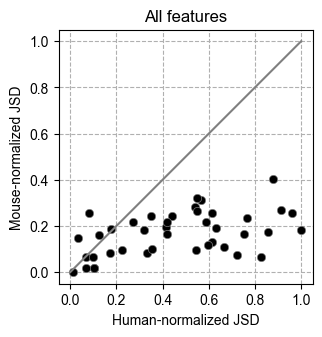

In [ ]:
ct1,ct2=homo_ct_list

JSD_list_m = []
JSD_list_h = []
for tmpi,feat in enumerate(df_morpho_mouse_homo_stand.columns[:-1]):
    tmparr1 = df_morpho_mouse_homo_stand[feat].values[df_mouse_mrmrdata.homologous==1]
    tmparr2 = df_morpho_mouse_homo_stand[feat].values[df_mouse_mrmrdata.homologous==2]
    nmi_score,_,_,_,_ = DIFF_feat_ct(tmparr1,tmparr2,method='JSD',stat_test=False)
    JSD_list_m.append(nmi_score)
for tmpi,feat in enumerate(df_morpho_human_homo_stand.columns[:-1]):
    tmparr1 = df_morpho_human_homo_stand[feat].values[df_human_mrmrdata.homologous==1]
    tmparr2 = df_morpho_human_homo_stand[feat].values[df_human_mrmrdata.homologous==2]
    nmi_score,_,_,_,_ = DIFF_feat_ct(tmparr1,tmparr2,method='JSD',stat_test=False)
    JSD_list_h.append(nmi_score)
JSD_list_m = np.array(JSD_list_m)
JSD_list_h = np.array(JSD_list_h)
xy_max = np.max([np.max(JSD_list_h),np.max(JSD_list_m)])
JSD_list_m = JSD_list_m/xy_max
JSD_list_h = JSD_list_h/xy_max

fig,ax = plt.subplots(1,1,figsize=(3.3,3.3))
ax.set_aspect('equal', adjustable='box')
sns.scatterplot(x=JSD_list_h,y=JSD_list_m,color='black',zorder=11,edgecolor='gray')
ax.plot((0,1),(0,1),color='gray',zorder=12)
ax.grid(ls='--')
ax.set_xlabel('Human-normalized JSD')
ax.set_ylabel('Mouse-normalized JSD')
ax.set_title('All features')
plt.show()

In [ ]:
# df_sourcedata = pd.DataFrame(np.array([JSD_list_h, JSD_list_m]).T, columns=['human','mouse'])
# df_sourcedata['feature'] = df_morpho_human_homo_stand.columns[:-1]
# df_sourcedata.to_csv(rf"..\Tables\source_data\Fig_6_JSD_{homo_ct_list[0]}_{homo_ct_list[1]}.csv", index=False)

R50_B_Total Length
R50_A_Avg. Straightness
R50_B_Avg. Straightness
R50_B_L2 Branch Num
R50_B_3D Density


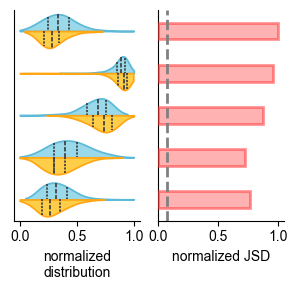

In [ ]:
fig,axs = plt.subplots(1,2,figsize=(3,3),sharey=True)
bias=0.0
alpha=0.5
barlw=2.0
axs[1].invert_yaxis()
selecttop = 5
eps=1e-10

np.random.seed(821)
rand_tmparr1 = np.random.randn(np.sum(df_human_mrmrdata.homologous==1))
np.random.seed(821)
rand_tmparr2 = np.random.randn(np.sum(df_human_mrmrdata.homologous==2))
rand_nmi_score,_1,_2,_,_ = DIFF_feat_ct(rand_tmparr1,rand_tmparr2,method='JSD',stat_test=False)

nmi_score_list_hh = []
nmi_score_list_hm = []
for tmpi,feat in enumerate(selected_feat_human[:selecttop]):
    tmparr1 = df_morpho_human_homo_stand[feat].values[df_human_mrmrdata.homologous==1]
    tmparr2 = df_morpho_human_homo_stand[feat].values[df_human_mrmrdata.homologous==2]
    nmi_score_h,_1,_2,_,_ = DIFF_feat_ct(tmparr1,tmparr2, method='JSD',stat_test=False)
    nmi_score_list_hh.append(nmi_score_h)
    # print(nmi_score,len(tmparr1),len(tmparr2),_1,_2)
    tmparr1 = df_morpho_mouse_homo_stand[feat].values[df_mouse_mrmrdata.homologous==1]
    tmparr2 = df_morpho_mouse_homo_stand[feat].values[df_mouse_mrmrdata.homologous==2]
    nmi_score_m,_1,_2,_,_ = DIFF_feat_ct(tmparr1,tmparr2, method='JSD',stat_test=False)
    nmi_score_list_hm.append(nmi_score_m)
    # print(nmi_score,len(tmparr1),len(tmparr2),_1,_2)
    
    axs[1].barh(tmpi+bias,nmi_score_h/xy_max,zorder=11,color=color2,edgecolor=color2**2,alpha=alpha,lw=barlw,height=0.4)
    print(selected_feat_human[:selecttop][tmpi])
    # axs[1].text(0,tmpi,selected_feat_human[:selecttop][tmpi],verticalalignment='center',horizontalalignment='left',zorder=13)
    # print(nmi_score)

axs[1].axvline(rand_nmi_score/xy_max,ls='--',color='gray',lw=barlw,zorder=12)
axs[1].grid(axis='y',which='both',linestyle='--')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
# axs[1].set_yticks([])
axs[1].set_ylim(selecttop, -1)
axs[1].set_yticks(np.arange(0,selecttop)+0.425)
axs[1].set_yticklabels([])
axs[1].set_xlim(right=1*1.05)

arrx1list = np.array([])
arrx2list = np.array([])
arry1list = np.array([])
arry2list = np.array([])
ct1,ct2=homo_ct_list
for tmpi, feat in enumerate(selected_feat_human[:selecttop]):
    tmparr1 = df_morpho_human_homo_stand[feat].values[df_morpho_human_homo_stand['homologous']==ct1].copy()
    tmparr2 = df_morpho_human_homo_stand[feat].values[df_morpho_human_homo_stand['homologous']==ct2].copy()

    
    Q11,Q12,Q13=np.percentile(tmparr1, [25,50,75])
    IQR1 = Q13-Q11
    lowb1,highb1 = Q11-1.5*IQR1, Q13+1.5*IQR1
    Q21,Q22,Q23=np.percentile(tmparr2, [25,50,75])
    IQR2 = Q23-Q21
    lowb2,highb2 = Q21-1.5*IQR2, Q23+1.5*IQR2
    lowb = min(lowb1, lowb2)
    highb = max(highb1, highb2)
    
    # tmparr1 = tmparr1[(tmparr1>=lowb)&(tmparr1<=highb)]            
    # tmparr2 = tmparr2[(tmparr2>=lowb)&(tmparr2<=highb)]
    tmparr_min = min(np.min(tmparr1),np.min(tmparr2))
    tmparr_max = max(np.max(tmparr1),np.max(tmparr2))
    
    tmparr1 = (tmparr1-tmparr_min) / (tmparr_max-tmparr_min+eps)
    tmparr2 = (tmparr2-tmparr_min) / (tmparr_max-tmparr_min+eps)

    arrx1list = np.hstack([arrx1list,tmparr1])
    arrx2list = np.hstack([arrx2list,tmparr2])
    arry1list = np.hstack([arry1list,np.array([tmpi]*len(tmparr1))])
    arry2list = np.hstack([arry2list,np.array([tmpi]*len(tmparr2))])

    
g=sns.violinplot(x=np.hstack([arrx1list,arrx2list]),y=np.hstack([arry1list,arry2list]).astype(int),
               hue=np.array([ct1]*len(arrx1list)+[ct2]*len(arrx2list)),
               split=True,inner='quartile',orient='h',ax=axs[0],cut=0,bw_adjust=1.5,width=0.8,density_norm='width')
ct1_c = homo_color_lut.get(ct1)
ct2_c = homo_color_lut.get(ct2)
for ind, violin in enumerate(g.findobj(matplotlib.collections.PolyCollection)):
    if ind % 2 != 0:
        violin.set_facecolor(ct1_c)
        violin.set_edgecolor(ct1_c**2)
    else:
        violin.set_facecolor(ct2_c)
        violin.set_edgecolor(ct2_c**2)
g.legend_.set_visible(False)
   
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].grid(axis='y',which='both',linestyle='--')
axs[0].set_yticks([])
axs[0].set_xlabel('normalized\ndistribution')
axs[1].set_xlabel('normalized JSD')

max_JSD_value = axs[1].get_xlim()[1]
# max_JSD_value = 1

fig.tight_layout(pad=1.08)
plt.show()

R50_B_Avg. Straightness
R50_B_L4 Branch Num
R50_B_Center Shift
R50_B_L1 Branch Length
R50_A_Max Branch Order


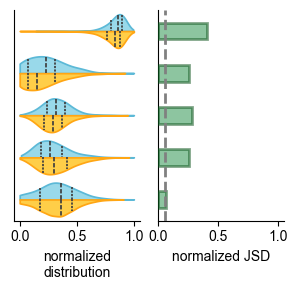

In [ ]:
fig,axs = plt.subplots(1,2,figsize=(3,3),sharey=True)
bias=0.0
alpha=0.5
barlw=2.0
axs[1].invert_yaxis()
selecttop = 5
eps=1e-10

np.random.seed(821)
rand_tmparr1 = np.random.randn(np.sum(df_mouse_mrmrdata.homologous==1))
np.random.seed(821)
rand_tmparr2 = np.random.randn(np.sum(df_mouse_mrmrdata.homologous==2))
rand_nmi_score,_,_,_,_ = DIFF_feat_ct(rand_tmparr1,rand_tmparr2,method='JSD',stat_test=False)

nmi_score_list_mh = []
nmi_score_list_mm = []
for tmpi,feat in enumerate(selected_feat_mouse[:selecttop]):
    tmparr1 = df_morpho_mouse_homo_stand[feat].values[df_mouse_mrmrdata.homologous==1]
    tmparr2 = df_morpho_mouse_homo_stand[feat].values[df_mouse_mrmrdata.homologous==2]
    nmi_score_m,_,_,_,_ = DIFF_feat_ct(tmparr1,tmparr2,method='JSD',stat_test=False)
    nmi_score_list_mm.append(nmi_score_m)
    # print(nmi_score,len(tmparr1),len(tmparr2),_1,_2)
    tmparr1 = df_morpho_human_homo_stand[feat].values[df_human_mrmrdata.homologous==1]
    tmparr2 = df_morpho_human_homo_stand[feat].values[df_human_mrmrdata.homologous==2]
    nmi_score_h,_,_,_,_ = DIFF_feat_ct(tmparr1,tmparr2,method='JSD',stat_test=False)
    nmi_score_list_mh.append(nmi_score_h)
    # print(nmi_score,len(tmparr1),len(tmparr2),_1,_2)
    
    axs[1].barh(tmpi+bias,nmi_score_m/xy_max,zorder=11,color=color1,edgecolor=color1**2,alpha=alpha,lw=barlw,height=0.4)
    print(selected_feat_mouse[:selecttop][tmpi])
    # axs[1].text(0,tmpi,selected_feat_mouse[:selecttop][tmpi],verticalalignment='center',horizontalalignment='left',zorder=13)
    # print(nmi_score)
    
axs[1].axvline(rand_nmi_score/xy_max,ls='--',color='gray',lw=barlw,zorder=12)
axs[1].grid(axis='y',which='both',linestyle='--')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
# axs[1].set_yticks([])
axs[1].set_ylim(selecttop, -1)
axs[1].set_yticks(np.arange(0,selecttop)+0.425)
axs[1].set_yticklabels([])
axs[1].set_xlim(right=max_JSD_value)

arrx1list = np.array([])
arrx2list = np.array([])
arry1list = np.array([])
arry2list = np.array([])
ct1,ct2=homo_ct_list
for tmpi, feat in enumerate(selected_feat_mouse[:selecttop]):
    tmparr1 = df_morpho_mouse_homo_stand[feat].values[df_morpho_mouse_homo_stand['homologous']==ct1].copy()
    tmparr2 = df_morpho_mouse_homo_stand[feat].values[df_morpho_mouse_homo_stand['homologous']==ct2].copy()

    
    Q11,Q12,Q13=np.percentile(tmparr1, [25,50,75])
    IQR1 = Q13-Q11
    lowb1,highb1 = Q11-1.5*IQR1, Q13+1.5*IQR1
    Q21,Q22,Q23=np.percentile(tmparr2, [25,50,75])
    IQR2 = Q23-Q21
    lowb2,highb2 = Q21-1.5*IQR2, Q23+1.5*IQR2
    lowb = min(lowb1, lowb2)
    highb = max(highb1, highb2)
    
    
    # tmparr1 = tmparr1[(tmparr1>=lowb)&(tmparr1<=highb)]            
    # tmparr2 = tmparr2[(tmparr2>=lowb)&(tmparr2<=highb)]
    tmparr_min = min(np.min(tmparr1),np.min(tmparr2))
    tmparr_max = max(np.max(tmparr1),np.max(tmparr2))
    
    tmparr1 = (tmparr1-tmparr_min) / (tmparr_max-tmparr_min+eps)
    tmparr2 = (tmparr2-tmparr_min) / (tmparr_max-tmparr_min+eps)

    arrx1list = np.hstack([arrx1list,tmparr1])
    arrx2list = np.hstack([arrx2list,tmparr2])
    arry1list = np.hstack([arry1list,np.array([tmpi]*len(tmparr1))])
    arry2list = np.hstack([arry2list,np.array([tmpi]*len(tmparr2))])
    
g=sns.violinplot(x=np.hstack([arrx1list,arrx2list]),y=np.hstack([arry1list,arry2list]).astype(int),
               hue=np.array([ct1]*len(arrx1list)+[ct2]*len(arrx2list)),
               split=True,inner='quartile',orient='h',ax=axs[0],cut=0,width=0.8,bw_adjust=1.5,density_norm='width')
ct1_c = homo_color_lut.get(ct1)
ct2_c = homo_color_lut.get(ct2)
for ind, violin in enumerate(g.findobj(matplotlib.collections.PolyCollection)):
    if ind % 2 != 0:
        violin.set_facecolor(ct1_c)
        violin.set_edgecolor(ct1_c**2)
    else:
        violin.set_facecolor(ct2_c)
        violin.set_edgecolor(ct2_c**2)
g.legend_.set_visible(False)
   
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].grid(axis='y',which='both',linestyle='--')
axs[0].set_yticks([])
axs[0].set_xlabel('normalized\ndistribution')
axs[1].set_xlabel('normalized JSD')

fig.tight_layout(pad=1.08)
plt.show()

In [66]:
df_sourcedata = pd.DataFrame()
for tmpi, feat in enumerate(selected_feat_human[:selecttop]):
    tmparr1 = df_morpho_human_homo_stand[feat].values[df_morpho_human_homo_stand['homologous']==ct1].copy()
    tmparr2 = df_morpho_human_homo_stand[feat].values[df_morpho_human_homo_stand['homologous']==ct2].copy()
    
    Q11,Q12,Q13=np.percentile(tmparr1, [25,50,75])
    IQR1 = Q13-Q11
    lowb1,highb1 = Q11-1.5*IQR1, Q13+1.5*IQR1
    Q21,Q22,Q23=np.percentile(tmparr2, [25,50,75])
    IQR2 = Q23-Q21
    lowb2,highb2 = Q21-1.5*IQR2, Q23+1.5*IQR2
    lowb = min(lowb1, lowb2)
    highb = max(highb1, highb2)
    
    tmparr_min = min(np.min(tmparr1),np.min(tmparr2))
    tmparr_max = max(np.max(tmparr1),np.max(tmparr2))
    
    tmparr1 = (tmparr1-tmparr_min) / (tmparr_max-tmparr_min+eps)
    tmparr2 = (tmparr2-tmparr_min) / (tmparr_max-tmparr_min+eps)

    df_sourcedata = pd.concat([
        df_sourcedata,
        pd.DataFrame({
            'feature': [feat]*len(tmparr1),
            'value': tmparr1,
            'homologous': [ct1]*len(tmparr1),
            'species': ['human']*len(tmparr1)
        }),
        pd.DataFrame({
            'feature': [feat]*len(tmparr2),
            'value': tmparr2,
            'homologous': [ct2]*len(tmparr2),
            'species': ['human']*len(tmparr2)
        })
    ], ignore_index=True)
    
for tmpi, feat in enumerate(selected_feat_mouse[:selecttop]):
    tmparr1 = df_morpho_mouse_homo_stand[feat].values[df_morpho_mouse_homo_stand['homologous']==ct1].copy()
    tmparr2 = df_morpho_mouse_homo_stand[feat].values[df_morpho_mouse_homo_stand['homologous']==ct2].copy()
    
    Q11,Q12,Q13=np.percentile(tmparr1, [25,50,75])
    IQR1 = Q13-Q11
    lowb1,highb1 = Q11-1.5*IQR1, Q13+1.5*IQR1
    Q21,Q22,Q23=np.percentile(tmparr2, [25,50,75])
    IQR2 = Q23-Q21
    lowb2,highb2 = Q21-1.5*IQR2, Q23+1.5*IQR2
    lowb = min(lowb1, lowb2)
    highb = max(highb1, highb2)
    
    tmparr_min = min(np.min(tmparr1),np.min(tmparr2))
    tmparr_max = max(np.max(tmparr1),np.max(tmparr2))
    
    tmparr1 = (tmparr1-tmparr_min) / (tmparr_max-tmparr_min+eps)
    tmparr2 = (tmparr2-tmparr_min) / (tmparr_max-tmparr_min+eps)

    df_sourcedata = pd.concat([
        df_sourcedata,
        pd.DataFrame({
            'feature': [feat]*len(tmparr1),
            'value': tmparr1,
            'homologous': [ct1]*len(tmparr1),
            'species': ['mouse']*len(tmparr1)
        }),
        pd.DataFrame({
            'feature': [feat]*len(tmparr2),
            'value': tmparr2,
            'homologous': [ct2]*len(tmparr2),
            'species': ['mouse']*len(tmparr2)
        })
    ], ignore_index=True)
    
# df_sourcedata.to_csv(rf"E:\ZhixiYun\Projects\fMOST_atlas\Tables\source_data\Fig_6_distribution_{homo_ct_list[0]}_{homo_ct_list[1]}.csv", index=False)
df_sourcedata

,feature,value,homologous,species
0,R50_B_Total Length,0.218368,FL,human
1,R50_B_Total Length,0.301575,FL,human
2,R50_B_Total Length,0.100141,FL,human
3,R50_B_Total Length,0.258594,FL,human
4,R50_B_Total Length,0.141317,FL,human
...,...,...,...,...
23485,R50_A_Max Branch Order,0.181818,PL,mouse
23486,R50_A_Max Branch Order,0.181818,PL,mouse
23487,R50_A_Max Branch Order,0.090909,PL,mouse
23488,R50_A_Max Branch Order,0.181818,PL,mouse


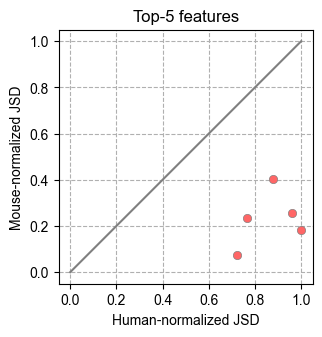

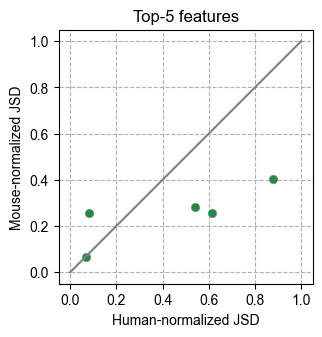

In [ ]:
# xy_max = np.max([np.max(nmi_score_list_hh),np.max(nmi_score_list_hm),np.max(nmi_score_list_mh),np.max(nmi_score_list_mm)])

fig,ax = plt.subplots(1,1,figsize=(3.3,3.3))
ax.set_aspect('equal', adjustable='box')
sns.scatterplot(x=np.array(nmi_score_list_hh)/xy_max,y=np.array(nmi_score_list_hm)/xy_max,color=color2,zorder=11,edgecolor='gray')
ax.plot((0,1),(0,1),color='gray',zorder=12)
ax.grid(ls='--')
ax.set_xlabel('Human-normalized JSD')
ax.set_ylabel('Mouse-normalized JSD')
ax.set_title('Top-5 features')
# fig.savefig(rf'E:\ZhixiYun\Projects\fMOST_atlas\Figures\Homologous\analysis\diff_region_diff\diff_distribution\top5_mRMR\h_top5_features_{ct1}_{ct2}_JSD.svg',
#                     transparent=True, bbox_inches='tight', dpi=500)
plt.show()

fig,ax = plt.subplots(1,1,figsize=(3.3,3.3))
ax.set_aspect('equal', adjustable='box')
sns.scatterplot(x=np.array(nmi_score_list_mh)/xy_max,y=np.array(nmi_score_list_mm)/xy_max,color=color1,zorder=11,edgecolor='gray')
ax.plot((0,1),(0,1),color='gray',zorder=12)
ax.grid(ls='--')
ax.set_xlabel('Human-normalized JSD')
ax.set_ylabel('Mouse-normalized JSD')
ax.set_title('Top-5 features')
plt.show()

In [68]:
selected_model = ['RF']
mean_mat_human = np.zeros((len(selected_feat_human),len(selected_model),len(SCORE_LIST)))
std_mat_human = np.zeros((len(selected_feat_human),len(selected_model),len(SCORE_LIST)))

train_mean_mat_human = np.zeros((len(selected_feat_human),len(selected_model),len(SCORE_LIST)))
train_std_mat_human = np.zeros((len(selected_feat_human),len(selected_model),len(SCORE_LIST)))

for i in range(len(selected_feat_human)):
    feat = selected_feat_human[i]
    for j in range(len(selected_model)):
        model = selected_model[j]
        # mRMR features
        test_mean_,test_std_,train_mean_,train_std_=classification(df_morpho_human_homo[selected_feat_human[:i+1]],df_morpho_human_homo['homologous'],model,n_components=None)
        # # PCA features
        # test_mean_,test_std_,train_mean_,train_std_=classification(df_morpho_human_homo[selected_feat_human],df_morpho_human_homo['homologous'],model,n_components=i+1)
        
        mean_mat_human[i,j] = test_mean_
        std_mat_human[i,j] = test_std_
        train_mean_mat_human[i,j] = train_mean_
        train_std_mat_human[i,j] = train_std_

Best parameters: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500, 'random_state': 821}
train:0.656±0.003 test:0.605±0.029
Best parameters: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 100, 'random_state': 821}
train:0.698±0.013 test:0.616±0.020
Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500, 'random_state': 821}
train:0.755±0.010 test:0.644±0.032
Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 821}
train:0.764±0.005 test:0.650±0.033
Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 300, 'random_state': 821}
train:0.791±0.008 test:0.666±0.039
Best parameters: {'class_weight': 'balanced', 'max_depth': 4, 'ma

In [69]:
df_sourcedata = pd.concat([
pd.concat([
        pd.Series(['human']*train_mean_mat_human.shape[0], name="species"), 
        pd.Series(['train']*train_mean_mat_human.shape[0], name="stage"), 
        pd.Series(np.arange(train_mean_mat_human.shape[0])+1, name="feature_num"), 
        pd.DataFrame(train_mean_mat_human.squeeze(axis=1), columns=SCORE_LIST)
    ], axis=1),
pd.concat([
        pd.Series(['human']*mean_mat_human.shape[0], name="species"), 
        pd.Series(['test']*mean_mat_human.shape[0], name="stage"), 
        pd.Series(np.arange(mean_mat_human.shape[0])+1, name="feature_num"), 
        pd.DataFrame(mean_mat_human.squeeze(axis=1), columns=SCORE_LIST)
    ], axis=1),
], ignore_index=True)
# df_sourcedata.to_csv(rf"E:\ZhixiYun\Projects\fMOST_atlas\Tables\source_data\Fig_6A_EDF_classification_scores_human_{homo_ct_list[0]}_{homo_ct_list[1]}.csv", index=False)


In [70]:
selected_model = ['RF']
mean_mat_mouse = np.zeros((len(selected_feat_mouse),len(selected_model),len(SCORE_LIST)))
std_mat_mouse = np.zeros((len(selected_feat_mouse),len(selected_model),len(SCORE_LIST)))

train_mean_mat_mouse = np.zeros((len(selected_feat_mouse),len(selected_model),len(SCORE_LIST)))
train_std_mat_mouse = np.zeros((len(selected_feat_mouse),len(selected_model),len(SCORE_LIST)))

for i in range(len(selected_feat_mouse)):
    feat = selected_feat_mouse[i]
    for j in range(len(selected_model)):
        model = selected_model[j]
        # mRMR features
        test_mean_,test_std_,train_mean_,train_std_=classification(df_morpho_mouse_homo[selected_feat_mouse[:i+1]],df_morpho_mouse_homo['homologous'],model, n_components=None)    
        # # PCA features
        # test_mean_,test_std_,train_mean_,train_std_=classification(df_morpho_mouse_homo[selected_feat_mouse],df_morpho_mouse_homo['homologous'],model,n_components=i+1)
        
        mean_mat_mouse[i,j] = test_mean_
        std_mat_mouse[i,j] = test_std_
        train_mean_mat_mouse[i,j] = train_mean_
        train_std_mat_mouse[i,j] = train_std_

Best parameters: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500, 'random_state': 821}
train:0.592±0.007 test:0.539±0.010
Best parameters: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 3, 'n_estimators': 500, 'random_state': 821}
train:0.596±0.005 test:0.571±0.016
Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 300, 'random_state': 821}
train:0.640±0.006 test:0.577±0.006
Best parameters: {'class_weight': 'balanced', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300, 'random_state': 821}
train:0.628±0.004 test:0.590±0.007
Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 821}
train:0.657±0.006 test:0.589±0.011
Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'ma

In [71]:
df_sourcedata = pd.concat([
pd.concat([
        pd.Series(['mouse']*train_mean_mat_mouse.shape[0], name="species"), 
        pd.Series(['train']*train_mean_mat_mouse.shape[0], name="stage"), 
        pd.Series(np.arange(train_mean_mat_mouse.shape[0])+1, name="feature_num"), 
        pd.DataFrame(train_mean_mat_mouse.squeeze(axis=1), columns=SCORE_LIST)
    ], axis=1),
pd.concat([
        pd.Series(['mouse']*mean_mat_mouse.shape[0], name="species"), 
        pd.Series(['test']*mean_mat_mouse.shape[0], name="stage"), 
        pd.Series(np.arange(mean_mat_mouse.shape[0])+1, name="feature_num"), 
        pd.DataFrame(mean_mat_mouse.squeeze(axis=1), columns=SCORE_LIST)
    ], axis=1),
], ignore_index=True)
# df_sourcedata.to_csv(rf"E:\ZhixiYun\Projects\fMOST_atlas\Tables\source_data\Fig_6A_EDF_classification_scores_mouse_{homo_ct_list[0]}_{homo_ct_list[1]}.csv", index=False)


In [ ]:
t_stat, p_value = wilcoxon(mean_mat_human[::2,0,0].flatten(),mean_mat_mouse[::2,0,0].flatten())
print(t_stat, p_value)

def cohens_d(a, b):
    n1,n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1-1)*np.std(a, ddof=1)**2 + (n2-1)*np.std(b, ddof=1)**2) / (n1+n2-2))
    cohens_d = (np.mean(a) - np.mean(b)) / pooled_std
    return cohens_d

cohens_d(mean_mat_human[::2,0,0].flatten(),mean_mat_mouse[::2,0,0].flatten())

0.0 9.5367431640625e-07


5.665078767192968

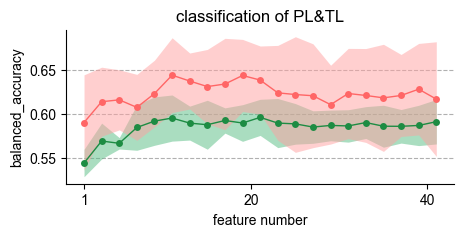

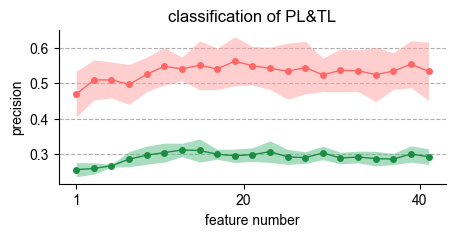

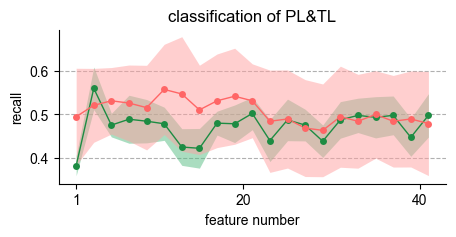

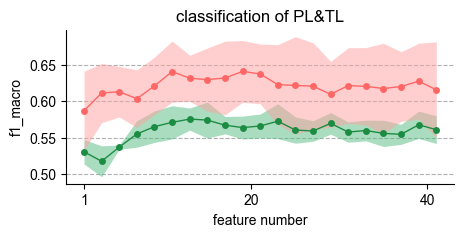

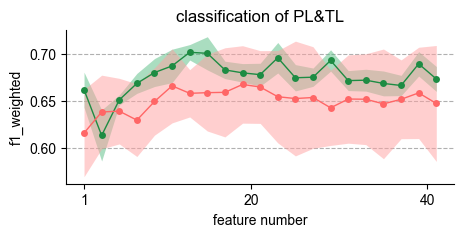

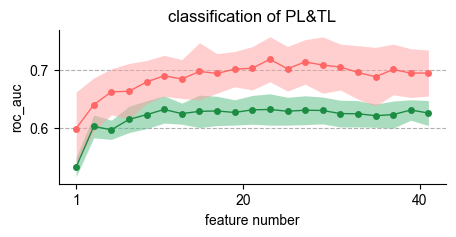

In [ ]:
for model_idx,model in enumerate(selected_model):
    for score_idx,score in enumerate(SCORE_LIST): 
        fig, ax = plt.subplots(1,1,figsize=(5,2))
        # fig.set_facecolor(np.array([243,255,162])/255.0)
        # ax.set_facecolor(np.array([231,251,191])/255.0)
        bias=0.0
        
        
        ax.fill_between(x=np.arange(1,len(mean_mat_mouse)+1,2)-bias, y1=mean_mat_mouse[::2,model_idx,score_idx]-std_mat_mouse[::2,model_idx,score_idx],
                        y2=mean_mat_mouse[::2,model_idx,score_idx]+std_mat_mouse[::2,model_idx,score_idx],color=color1**0.5,alpha=0.5,lw=0,zorder=10)
        ax.plot(np.arange(1,len(mean_mat_mouse)+1,2)-bias, mean_mat_mouse[::2,model_idx,score_idx],color=color1,lw=1,label='mouse',zorder=11)
        ax.scatter(np.arange(1,len(mean_mat_mouse)+1,2)-bias, mean_mat_mouse[::2,model_idx,score_idx],color=color1,lw=0,zorder=12,s=25)
        
        ax.fill_between(x=np.arange(1,len(mean_mat_human)+1,2)-bias, y1=mean_mat_human[::2,model_idx,score_idx]-std_mat_human[::2,model_idx,score_idx],
                        y2=mean_mat_human[::2,model_idx,score_idx]+std_mat_human[::2,model_idx,score_idx],color=color2**0.5,alpha=0.5,lw=0,zorder=10)
        ax.plot(np.arange(1,len(mean_mat_human)+1,2)-bias, mean_mat_human[::2,model_idx,score_idx],color=color2,lw=1,label='human',zorder=11)
        ax.scatter(np.arange(1,len(mean_mat_human)+1,2)-bias, mean_mat_human[::2,model_idx,score_idx],color=color2,lw=0,zorder=12,s=25)


        # # # with train score
        # ax.fill_between(x=np.arange(1,len(train_mean_mat_mouse)+1,1)-bias, y1=train_mean_mat_mouse[:,model_idx,score_idx]-train_std_mat_mouse[:,model_idx,score_idx],
        #                 y2=train_mean_mat_mouse[:,model_idx,score_idx]+train_std_mat_mouse[:,model_idx,score_idx],color=color1**0.5,alpha=0.5,lw=0,zorder=10)
        # ax.plot(np.arange(1,len(train_mean_mat_mouse)+1,1)-bias, train_mean_mat_mouse[:,model_idx,score_idx],color=color1**1,lw=1,label='mouse_train',zorder=11,ls='--')
        # ax.scatter(np.arange(1,len(train_mean_mat_mouse)+1,1)-bias, train_mean_mat_mouse[:,model_idx,score_idx],color=color1**1,lw=0,zorder=12,s=30,marker='^')
        
        # ax.fill_between(x=np.arange(1,len(train_mean_mat_human)+1,1)-bias, y1=train_mean_mat_human[:,model_idx,score_idx]-train_std_mat_human[:,model_idx,score_idx],
        #                 y2=train_mean_mat_human[:,model_idx,score_idx]+train_std_mat_human[:,model_idx,score_idx],color=color2**0.5,alpha=0.5,lw=0,zorder=10)
        # ax.plot(np.arange(1,len(train_mean_mat_human)+1,1)-bias, train_mean_mat_human[:,model_idx,score_idx],color=color2**1,lw=1,label='human_train',zorder=11,ls='--')
        # ax.scatter(np.arange(1,len(train_mean_mat_human)+1,1)-bias, train_mean_mat_human[:,model_idx,score_idx],color=color2**1,lw=0,zorder=12,s=30,marker='^')
        
        
        
        ax.set_title(f"classification of {homo_ct_list[0]}&{homo_ct_list[1]}")
        ax.set_ylabel(score)
        ax.set_xlabel('feature number')
        
        ax.set_xticks([1]+np.arange(20,len(mean_mat_mouse)+1,20).tolist())
        # ax.legend(loc=0).set_zorder(13)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
        ax.grid(axis='y',ls='--')
        
     
        plt.show()
        # break
